#**Assignment 3**

#Question 1: Explain the difference between:
● "r", "w", "a", "rb"
● Why context managers (with open()) are preferred
● What happens if a file is not properly closed in a production system

**Answers-**

##1)

- r = "r" stands for read. It opens a file for reading. The file must already exist.
- w = "w" stands for write. It opens a file for writing and existing content is overwritten or a new file is created if it doesn't exist.
- a = "a" stands for append. It opens a file for appending data at the end without removing exsisting content.
- rb = "rb" stands for read binary. It opens a file for reading binary data such as images, videos, audio files or PDFs.


##2)
 Context managers handles the opening and closing files automatically. when We use with open(), python ensure that file is closed properly after the block of code is executed, even if an error occurs.

Example:-

 with open("data.txt", "r") as file:
    content = file.read()

Using context managers makes the code cleaner, safer and easier to maintain and also reduces the chance of resource leaks caused by forgetting to close files manually.


##3)
If a file is not properly closed in a production system it will lead to resource leak and inefficient memory usage. The file may remain locked, preventing other programs or users from accessing it. Unsaved data may also be lost because buffered data is not written completely to the file. As in large-scale production system that handles thousands of files, unclosed files can exhaust system resources and negatively affect reliability, stability and also the performance.


#Question 2: You are given a CSV file sales.csv containing:
product,price,quantity
Laptop,50000,5
Phone,20000,10
Tablet,15000,7

Tasks:
1. Read the file using Python.
2. Compute total revenue per product
3. Write results to a new file revenue.csv.
4. Explain limitations of manual CSV handling vs Pandas.


**Answers-**


In [5]:
#Note (creating csv file)
import csv

with open("sales.csv", "w", newline="") as file:
    writer = csv.writer(file)

    # Writing header
    writer.writerow(["product", "price", "quantity"])

    # Writing data
    writer.writerow(["Laptop", 50000, 5])
    writer.writerow(["Phone", 20000, 10])
    writer.writerow(["Tablet", 15000, 7])

print("sales.csv file created successfully")

sales.csv file created successfully


In [6]:
#1) read the csv file using python
import csv

with open("sales.csv", "r") as file:
    reader = csv.reader(file)
    next(reader)  # skip header

    for row in reader:
        print(row)

['Laptop', '50000', '5']
['Phone', '20000', '10']
['Tablet', '15000', '7']


In [8]:
#2) compute total revenue per product
import csv

with open("sales.csv", "r") as file:
    reader = csv.reader(file)
    next(reader)

    for row in reader:
        product = row[0]
        price = int(row[1])
        quantity = int(row[2])

        revenue = price * quantity
        print(product, "Revenue:", revenue)

Laptop Revenue: 250000
Phone Revenue: 200000
Tablet Revenue: 105000


In [9]:
#3) write results to new file
import csv

with open("sales.csv", "r") as file:
    reader = csv.reader(file)
    next(reader)

    with open("revenue.csv", "w", newline="") as output:
        writer = csv.writer(output)

        writer.writerow(["Product", "Revenue"])

        for row in reader:
            product = row[0]
            price = int(row[1])
            quantity = int(row[2])

            revenue = price * quantity
            writer.writerow([product, revenue])

print("revenue.csv created successfully")


revenue.csv created successfully


4)Explain limitations of manual CSV handling vs Pandas.

- manual csv file handling in python requires writing the extra codes for reading files, converting the datatype and performing calculations. It becomes difficult to manage when datasets become complex or large.

In pandas, it simplifies all these operations using built-in function like read_csv() , aggregation, filtering and grouping. It reduces the complexity of code and also improves the readibility and is highly efficient for the large datasets. This is the reason why the panda is widely used in real world data science and ML workflows.

#Question 3: You receive JSON data from an API:
{
"customers": [
{"id": 1, "name": "Amit", "purchase": 5000},
{"id": 2, "name": "Sara", "purchase": 7000}
]
}

Tasks:
1. Load the JSON.
2. Extract all customer names.
3. Compute total purchase value.
4. Explain why JSON is widely used in ML pipelines

**Answers**

In [11]:
#given JSON data
{
  "customers": [
    {"id": 1, "name": "Amit", "purchase": 5000},
    {"id": 2, "name": "Sara", "purchase": 7000}
  ]
}



#1) load the JSON data
import json

data = '''
{
  "customers": [
    {"id": 1, "name": "Amit", "purchase": 5000},
    {"id": 2, "name": "Sara", "purchase": 7000}
  ]
}
'''

json_data = json.loads(data)
print(json_data)

{'customers': [{'id': 1, 'name': 'Amit', 'purchase': 5000}, {'id': 2, 'name': 'Sara', 'purchase': 7000}]}


In [17]:
#2) extract all customer names
names = []

for customer in json_data["customers"]:
    names.append(customer["name"])

print(names)

['Amit', 'Sara']


In [16]:
#3) compare total purchase value
total_purchase = 0

for customer in json_data["customers"]:
    total_purchase += customer["purchase"]

print("Total Purchase:", total_purchase)

Total Purchase: 12000


4)Explain why JSON is widely used in ML pipelines

- JSON is widely used in ML pipelines because it is easy to read, supports data in key value format and also is lightweight. It is commonly used in the APIsfor the transferring of data between the systems.
JSON can also easily represnt the complex nested data like lists and dictionaries which makes it suitable for real world dataset.
It is also language independent, , means it can be used across python< JAVA and the other programming languages, making data integration nin ML system simple and efficient as well.

#Question 4:Create NumPy arrays for:
● Product prices
● Quantities

Then:
1. Compute revenue using vectorized operations.
2. Compare performance of Python loop vs NumPy.
3. Explain broadcasting with example

**Answers**

In [18]:
#creating Numpy Arrays
import numpy as np

prices = np.array([500, 1500, 2500, 800, 1200])
quantities = np.array([2, 3, 1, 5, 4])

In [19]:
#1) compute revenue using vectorized operations
revenue = prices * quantities
print(revenue)

[1000 4500 2500 4000 4800]


In [20]:
# 2) Compare performance of Python loop vs NumPy

#python loop approach
revenue = []

for i in range(len(prices)):
    revenue.append(prices[i] * quantities[i])

print(revenue)

[np.int64(1000), np.int64(4500), np.int64(2500), np.int64(4000), np.int64(4800)]


In [21]:
#Numpy approach
revenue = prices * quantities
print(revenue)

[1000 4500 2500 4000 4800]


Explanation

- python loops are slower because they process each element one by one
- Numpy is faster because it uses optimized C-based operations and vectorization
-in large datasets, Numpy significantly reduces computation time.


3) Explain broadcasting with example

- Broadcasting is a feature in Numpy that allows operations on arrays of different shapes by automatically expanding the smaller array.


In [23]:
## code example for above question
prices = np.array([500, 1000, 1500, 2000])

discount = 100

final_price = prices - discount

print(final_price)

[ 400  900 1400 1900]


Explanation
- here the discount was the single value but numpy automatically applies it to every element in the array. THis is called broadcasting. It also avoids explicit loops and makes the computation faster and cleaner.

#Question 5: Using sales data:
1. Plot line chart for monthly revenue.
2. Plot bar chart for product comparison.
3. Add labels, title, legend.
4. Explain why visualization is essential before modeling.


**Answers**

In [1]:
# given data
import matplotlib.pyplot as plt

months = ["Jan", "Feb", "Mar", "Apr", "May"]
monthly_revenue = [12000, 15000, 11000, 18000, 17000]

products = ["Laptop", "Phone", "Tablet"]
product_revenue = [250000, 200000, 105000]

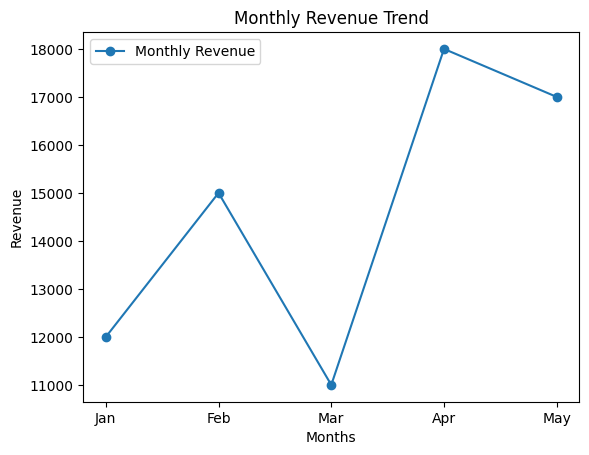

In [2]:
# 1) plot line chart for monthly revenue

plt.plot(months, monthly_revenue, marker='o', label="Monthly Revenue")

plt.title("Monthly Revenue Trend")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.legend()

plt.show()

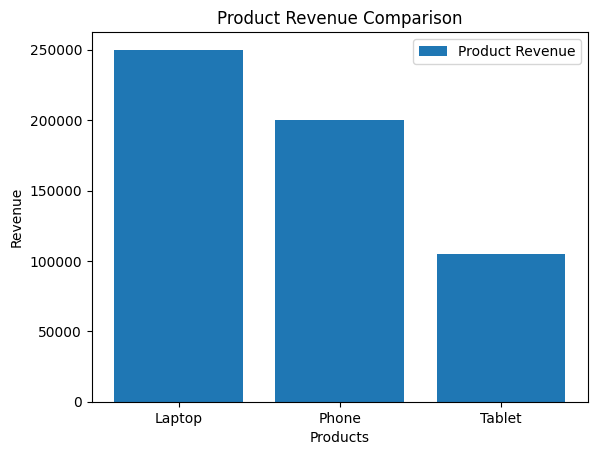

In [3]:
# 2) plot bar chart for product comparison

plt.bar(products, product_revenue, label="Product Revenue")

plt.title("Product Revenue Comparison")
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.legend()

plt.show()

- title = gives name of graph
- x-axis = shows categories (months/products)
- y-axis = shows numberic values (revenue)
- legend = explain what line/bar represnts

4) why visualization is important before modeling?

- Data visualization is an important step in the data analysis because it helps us in the understanding of the patterns, trends and also the relationships in the data before building the machine learning models.  It alaso allows us to detect the missing values , detection of outliers and also the inconsistencies thta can affect the performance.
visualization is also helpuful in selecting important features and understanding of data distribution. And without visualization models may be trained on unclean or misleading data which can reduce accuracy.
Therefore, it acts as a foundation step in data sceince workflow to ensure better decison making and model performance.

#Question 6: Load a CSV into Pandas and:
1. Display first 5 rows.
2. Check missing values.
3. Compute summary statistics.
4. Select rows where sales > 15000.

In [10]:
# load csv using Pandas

import pandas as pd

data = {
    "product": ["Laptop", "Phone", "Tablet"],
    "price": [50000, 20000, 15000],
    "quantity": [5, 10, 7]
}

df = pd.DataFrame(data)

df.to_csv("sales.csv", index=False)

print("CSV file created successfully")

CSV file created successfully


In [12]:
# load the csv
import pandas as pd

df = pd.read_csv("sales.csv")
print(df)

  product  price  quantity
0  Laptop  50000         5
1   Phone  20000        10
2  Tablet  15000         7


In [13]:
# 1) display first five rows

print(df.head())

  product  price  quantity
0  Laptop  50000         5
1   Phone  20000        10
2  Tablet  15000         7


In [14]:
# 2) check missing values

print(df.isnull().sum())

product     0
price       0
quantity    0
dtype: int64


In [15]:
# 3) compute summary statistics

print(df.describe())

              price   quantity
count      3.000000   3.000000
mean   28333.333333   7.333333
std    18929.694486   2.516611
min    15000.000000   5.000000
25%    17500.000000   6.000000
50%    20000.000000   7.000000
75%    35000.000000   8.500000
max    50000.000000  10.000000


In [16]:
# 4) Select rows where sales > 15000.

filtered_data = df[df["price"] * df["quantity"] > 15000]
print(filtered_data)

  product  price  quantity
0  Laptop  50000         5
1   Phone  20000        10
2  Tablet  15000         7


#Question 7: Dataset contains:
● Missing values
● Duplicate rows
● Inconsistent capitalization
Tasks:
1. Remove duplicates.
2. Handle missing values.
3. Standardize text columns.
4. Explain impact of dirty data on ML performance.

**Answers**

In [17]:
# sample dataset

import pandas as pd
import numpy as np

data = {
    "Name": ["Amit", "Sara", "amit", None, "John", "Sara"],
    "Sales": [5000, 7000, 5000, 6000, np.nan, 7000]
}

df = pd.DataFrame(data)

print(df)

   Name   Sales
0  Amit  5000.0
1  Sara  7000.0
2  amit  5000.0
3  None  6000.0
4  John     NaN
5  Sara  7000.0


In [18]:
# 1) remove duplicate

df = df.drop_duplicates()

print(df)

   Name   Sales
0  Amit  5000.0
1  Sara  7000.0
2  amit  5000.0
3  None  6000.0
4  John     NaN


In [19]:
# 2) handle missing values

df["Name"] = df["Name"].fillna("Unknown")
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

print(df)

      Name   Sales
0     Amit  5000.0
1     Sara  7000.0
2     amit  5000.0
3  Unknown  6000.0
4     John  5750.0


In [20]:
# 3) standardize text column

df["Name"] = df["Name"].str.title()

print(df)

      Name   Sales
0     Amit  5000.0
1     Sara  7000.0
2     Amit  5000.0
3  Unknown  6000.0
4     John  5750.0


4) impact of dirty data on ML performance

- dirty data can significantly reduce the performance of ML models. Missing values may cause errors or also the incorrect predictions while the duplicate records can bias the model by over-representing certain observations. Inconsistent text formatting can create the multiple categories for the same value which leads to inaccurate analysis.
poor quality data often results in the lower accuracy , inefficient model training and unreliable predictions.
Therefore the data cleaning is an important step before building any machine learning model.


#Question 8:Using Plotly:
1. Create interactive bar chart of sales.
2. Create pie chart for category distribution.
3. Add hover information.
4. Explain difference between:
○ Static visualization (Matplotlib/Seaborn)
○ Interactive dashboards (Plotly)
Discuss where interactive dashboards are critical in business environments.

In [21]:
# sample dataset

import pandas as pd

data = {
    "Product": ["Laptop", "Phone", "Tablet"],
    "Sales": [250000, 200000, 105000]
}

df = pd.DataFrame(data)

In [22]:
# 1) create interactive bar chart of sales
import plotly.express as px

fig = px.bar(
    df,
    x="Product",
    y="Sales",
    title="Product Sales Comparison",
    hover_data=["Sales"]
)

fig.show()

In [23]:
# 2) create a pie chart for category distribution

import plotly.express as px

fig = px.pie(
    df,
    names="Product",
    values="Sales",
    title="Sales Distribution by Product"
)

fig.show()

In [24]:
# 3) add hover information

import plotly.express as px

fig = px.bar(
    df,
    x="Product",
    y="Sales",
    hover_name="Product",
    hover_data=["Sales"]
)

fig.show()

4) difference between static visualization and interactive dashboards


- **Static visualization**

-> produces the fix chart and graphs

-> it is mainly used for reports and analysis

-> there is no zooom and hovering features in this

-> it is simpler and light weight


-**Interactive dashboards**

-> it allows the user interaction with charts

-> used for real time exploration of data

-> it supports zooming, filter, hovering and planning

-> it is more dynamic and user friendly.


5) where interactive dashboards are critical in business environments?

- interactive dashboards are critical in business environment because the decison makers often need to explore data in the real-time. They are widely used in the sales monitoring, customer analytics,supply chain management and also the business intelligence system.
Managers can filter the data , examine the trends and then identify performance issues instantlywithout genrating new reports.
Hence this improves decision making speed and helps organizations respond quickly to the changing business conditions.

#Question 9:
Write a Python program to:
1. Create a text file called data.txt
2. Write 5 lines of product information
3. Read the file and print only lines containing the word "Laptop"
4. Use a context manager
Explain why context managers prevent memory leaks.

In [25]:
# 1) Create a text file called data.txt
with open("data.txt", "w") as file:
    file.write("Laptop, 50000\n")
    file.write("Phone, 20000\n")
    file.write("Laptop Pro, 75000\n")
    file.write("Tablet, 15000\n")
    file.write("Laptop Air, 60000\n")

print("data.txt created successfully")

data.txt created successfully


In [27]:
# 2) Write 5 lines of product information

with open("data.txt", "w") as file:
    file.write("Laptop, 50000\n")
    file.write("Phone, 20000\n")
    file.write("Laptop Pro, 75000\n")
    file.write("Tablet, 15000\n")
    file.write("Laptop Air, 60000\n")

print("data.txt created successfully")

data.txt created successfully


In [28]:
# 3) Read the file and print only lines containing the word "Laptop"

with open("data.txt", "r") as file:
    for line in file:
        if "Laptop" in line:
            print(line.strip())

Laptop, 50000
Laptop Pro, 75000
Laptop Air, 60000


4) Use a context manager

In the above program, the statement

with open("data.txt", "w") as file:
and
with open("data.txt", "r") as file:

are example of **context manager**

5) explain why context manager prevents memory leaks?

- context manager helps in prevent the memory leaks by automatically closing files after they are used. If the files are left open , they continue consuming the system resources such as memorry and file handles.
In large applicationsmany unclosed files can reduce performance and may eventually exhaust available respurces. the with open() statement ensures that the files must be properly closed evne if an error occurs during execution, making programe safe , more efficient and easier to maintain.

#Question 10: You are hired as a Data Analyst at an online learning company.
The company offers multiple courses and wants to understand:
● Revenue trends
● Student performance
● Course popularity
● Engagement patterns
You must design a simple analytics solution using Python and Data Science tools.
Design a CSV file structure that stores:
● Course Name
● Student ID
● Course Fee
● Completion Percentage
● Rating (1–5)
Write a Python program to:
1. Create this CSV file.
2. Add at least 10 sample records.
3. Read the file and calculate total revenue.
Explain why using with open() is better than manually opening and closing files.

**Answers**

In [1]:
# 1 and 2
# creating a csv file and adding atleast 10 sample records

import csv

with open("courses.csv", "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow(["Course Name", "Student ID", "Course Fee", "Completion Percentage", "Rating"])

    writer.writerow(["Python", 101, 5000, 90, 5])
    writer.writerow(["Data Science", 102, 8000, 85, 4])
    writer.writerow(["Machine Learning", 103, 10000, 75, 4])
    writer.writerow(["Python", 104, 5000, 95, 5])
    writer.writerow(["Data Analysis", 105, 7000, 80, 4])
    writer.writerow(["SQL", 106, 4000, 88, 5])
    writer.writerow(["Python", 107, 5000, 70, 3])
    writer.writerow(["Machine Learning", 108, 10000, 92, 5])
    writer.writerow(["Data Science", 109, 8000, 78, 4])
    writer.writerow(["SQL", 110, 4000, 96, 5])

print("courses.csv created successfully")

courses.csv created successfully


In [2]:
# 3) read the file and calculate total revenue

import csv

total_revenue = 0

with open("courses.csv", "r") as file:
    reader = csv.reader(file)

    next(reader)  # Skip header

    for row in reader:
        total_revenue += int(row[2])

print("Total Revenue:", total_revenue)

Total Revenue: 66000


Q) **why using with open() is better than manually opening and closing files?**

-The with open() statement automatically closes the file after the code block is executed and that reduces the risk of forgetting to close the files and also prevents the resource leaks.
It also ensure that the files are properly closed even if an error occurs during the execution.
And as a result, programs become safer, easier to maintain and even more efficient.
In data science projects that handle many files, using with open() is considered the best practice.